Coordinate Finder Tool

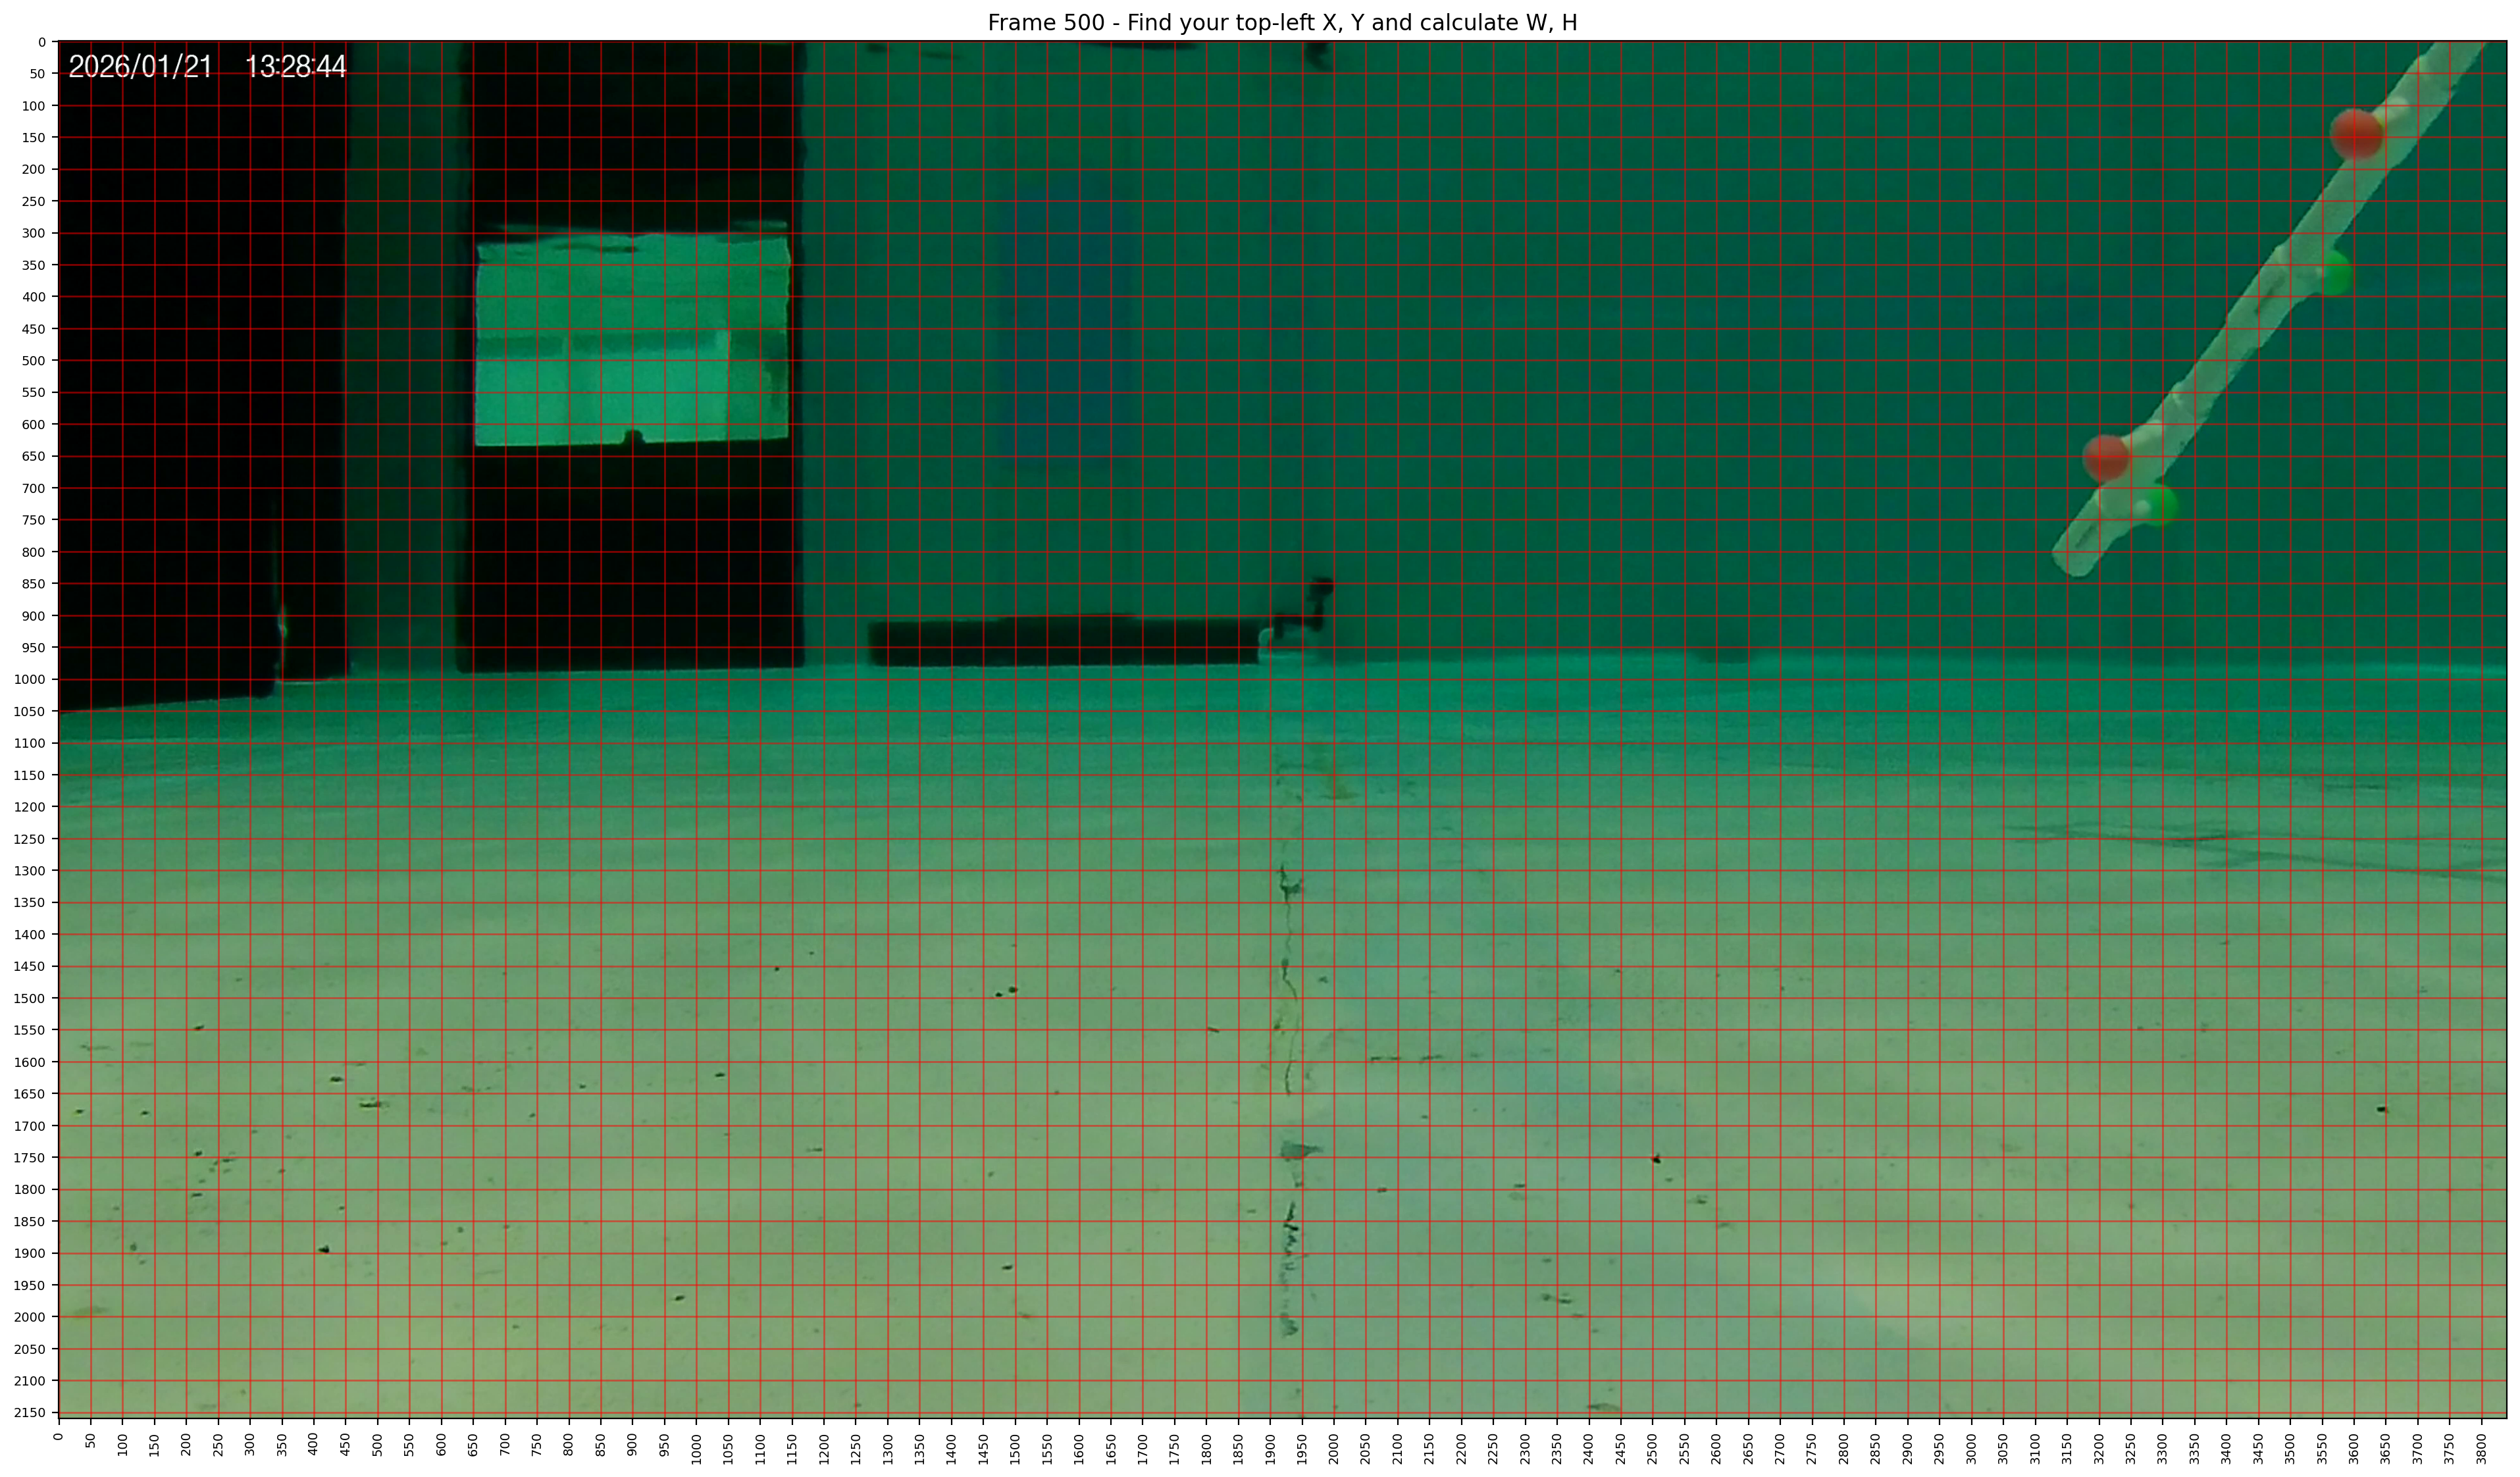


👇 Look at the axes above to find your box. Replace the variables in caps, then run in terminal 👇
ffmpeg -i "/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync.mp4" -vf "drawbox=x=YOUR_X:y=YOUR_Y:w=YOUR_W:h=YOUR_H:color=black:t=fill" "/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync_MASKED.mp4"


In [11]:
import cv2
import matplotlib.pyplot as plt

# --- CHANGE THIS FOR EACH VIDEO ---
current_video = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync.mp4'

cap = cv2.VideoCapture(current_video)
# Jump to the 500th frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 500)
ret, frame = cap.read()
cap.release()

if ret:
    # Convert BGR to RGB so colors look normal in matplotlib
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Create a large, high-res plot
    fig, ax = plt.subplots(figsize=(24, 14), dpi=200)
    ax.imshow(frame)
    
    # Overlay a grid to make reading coordinates easy
    plt.grid(color='red', linestyle='-', linewidth=1, alpha=0.5)
    
    # Add tick marks every 50 pixels
    ax.set_xticks(range(0, frame.shape[1], 50))
    ax.set_yticks(range(0, frame.shape[0], 50))
    plt.xticks(rotation=90, fontsize=7) 
    plt.yticks(fontsize=7)
    
    plt.title("Frame 500 - Find your top-left X, Y and calculate W, H")
    plt.show()
    
    out_video = current_video.replace('.mp4', '_MASKED.mp4')
    print("\n👇 Look at the axes above to find your box. Replace the variables in caps, then run in terminal 👇")
    print(f'ffmpeg -i "{current_video}" -vf "drawbox=x=YOUR_X:y=YOUR_Y:w=YOUR_W:h=YOUR_H:color=black:t=fill" "{out_video}"')
else:
    print("❌ Could not read the video file. Check the path or frame number.")

In [13]:
import cv2
import numpy as np
import os

# --- PATHS FOR VIDEO 4 (w3) ---
video_path = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync.mp4'
masked_path = video_path.replace('.mp4', '_MASKED.mp4')
mask_img_path = video_path.replace('.mp4', '_blackout_mask.png')

# Grab the exact resolution of the video
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("🎨 Drawing geometric mask for w3...")
# Create an empty transparent image
mask = np.zeros((height, width, 4), dtype=np.uint8)

# Define solid black (B, G, R, Alpha)
black = (0, 0, 0, 255)

# --- DRAW RECTANGLES ---
# The specific distractor box
cv2.rectangle(mask, (1900, 840), (2000, 950), black, -1)

# Save the transparent mask to disk
cv2.imwrite(mask_img_path, mask)

# Let FFmpeg handle the overlay
print("🚀 Overlaying mask onto video via FFmpeg...")
cmd = f'ffmpeg -hide_banner -loglevel error -y -i "{video_path}" -i "{mask_img_path}" -filter_complex "overlay=0:0" -c:v libx264 -preset fast -crf 18 -c:a copy "{masked_path}"'
os.system(cmd)

print(f"✅ Masked video saved to: {masked_path}")

🎨 Drawing geometric mask for w3...
🚀 Overlaying mask onto video via FFmpeg...
✅ Masked video saved to: /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync_MASKED.mp4


In [12]:
import cv2
import numpy as np
import os

# --- PATHS FOR VIDEO 3 (w2) ---
video_path = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w2_final_sync.mp4'
masked_path = video_path.replace('.mp4', '_MASKED.mp4')
mask_img_path = video_path.replace('.mp4', '_blackout_mask.png')

# Grab the exact resolution of the video
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("🎨 Drawing geometric mask for w2...")
# Create an empty transparent image
mask = np.zeros((height, width, 4), dtype=np.uint8)

# Define solid black (B, G, R, Alpha)
black = (0, 0, 0, 255)

# --- DRAW RECTANGLES ---
# Top blackout (Everything above Y: 700)
cv2.rectangle(mask, (0, 0), (width, 700), black, -1)

# Save the transparent mask to disk
cv2.imwrite(mask_img_path, mask)

# Let FFmpeg handle the overlay
print("🚀 Overlaying mask onto video via FFmpeg...")
cmd = f'ffmpeg -hide_banner -loglevel error -y -i "{video_path}" -i "{mask_img_path}" -filter_complex "overlay=0:0" -c:v libx264 -preset fast -crf 18 -c:a copy "{masked_path}"'
os.system(cmd)

print(f"✅ Masked video saved to: {masked_path}")

🎨 Drawing geometric mask for w2...
🚀 Overlaying mask onto video via FFmpeg...
✅ Masked video saved to: /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w2_final_sync_MASKED.mp4


In [8]:
import cv2
import numpy as np
import os

video_path = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_final_sync.mp4'
masked_path = video_path.replace('.mp4', '_MASKED.mp4')
mask_img_path = video_path.replace('.mp4', '_blackout_mask.png')

# 1. Grab the exact resolution of the video
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("🎨 Drawing geometric mask...")
# Create an empty transparent image
mask = np.zeros((height, width, 4), dtype=np.uint8)

# Define solid black (B, G, R, Alpha)
black = (0, 0, 0, 255)

# --- DRAW RECTANGLES ---
# Left wall (Everything left of 900)
cv2.rectangle(mask, (0, 0), (900, height), black, -1)
# Right wall (Everything right of 3350)
cv2.rectangle(mask, (3350, 0), (width, height), black, -1)

# The 4 distractor boxes
cv2.rectangle(mask, (2270, 60), (2290, 90), black, -1)
cv2.rectangle(mask, (2820, 1800), (2850, 1850), black, -1)
cv2.rectangle(mask, (2255, 2025), (2330, 2125), black, -1) # Flipped coordinates to standard min/max
cv2.rectangle(mask, (1175, 700), (1200, 750), black, -1)

# --- DRAW TRIANGLES ---
# Bottom Triangle (Right angle at 900, 2150)
pts1 = np.array([[900, 2150], [1700, 2150], [900, 1400]], np.int32)
cv2.fillPoly(mask, [pts1], black)

# Top Triangle (Right angle at 900, 0)
pts2 = np.array([[900, 0], [1450, 0], [900, 550]], np.int32)
cv2.fillPoly(mask, [pts2], black)

# Save the transparent mask to disk
cv2.imwrite(mask_img_path, mask)

# 2. Let FFmpeg handle the heavy lifting
print("🚀 Overlaying mask onto video via FFmpeg...")
cmd = f'ffmpeg -hide_banner -loglevel error -y -i "{video_path}" -i "{mask_img_path}" -filter_complex "overlay=0:0" -c:v libx264 -preset fast -crf 18 -c:a copy "{masked_path}"'
os.system(cmd)

print(f"✅ Masked video saved to: {masked_path}")

🎨 Drawing geometric mask...
🚀 Overlaying mask onto video via FFmpeg...
✅ Masked video saved to: /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_final_sync_MASKED.mp4


In [10]:
import cv2
import numpy as np
import os

# --- PATHS FOR VIDEO 2 (w1) ---
video_path = '/mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w1_final_sync.mp4'
masked_path = video_path.replace('.mp4', '_MASKED.mp4')
mask_img_path = video_path.replace('.mp4', '_blackout_mask.png')

# Grab the exact resolution of the video
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print("🎨 Drawing geometric mask for w1...")
# Create an empty transparent image
mask = np.zeros((height, width, 4), dtype=np.uint8)

# Define solid black (B, G, R, Alpha)
black = (0, 0, 0, 255)

# --- DRAW RECTANGLES ---
# Top blackout (Everything above Y: 700)
cv2.rectangle(mask, (0, 0), (width, 700), black, -1)

# The 3 specific distractor boxes
cv2.rectangle(mask, (230, 890), (275, 980), black, -1)
cv2.rectangle(mask, (160, 940), (230, 980), black, -1)
cv2.rectangle(mask, (2320, 1000), (2350, 1050), black, -1)

# Save the transparent mask to disk
cv2.imwrite(mask_img_path, mask)

# Let FFmpeg handle the overlay
print("🚀 Overlaying mask onto video via FFmpeg...")
cmd = f'ffmpeg -hide_banner -loglevel error -y -i "{video_path}" -i "{mask_img_path}" -filter_complex "overlay=0:0" -c:v libx264 -preset fast -crf 18 -c:a copy "{masked_path}"'
os.system(cmd)

print(f"✅ Masked video saved to: {masked_path}")

🎨 Drawing geometric mask for w1...
🚀 Overlaying mask onto video via FFmpeg...
✅ Masked video saved to: /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w1_final_sync_MASKED.mp4


Cell 1: Setup

In [1]:
import os
import glob
import cv2
import pandas as pd
import numpy as np
import json
import deeplabcut
import ruamel.yaml
import tensorflow as tf

TRIAL_DIR = '/mnt/Data/Projects/cloud_deployment/videos/Trial3'
WORKING_DIR = '/mnt/Data/Projects/cloud_deployment/Scripts'
CAMERAS = ['t3tp', 't3w1', 't3w2', 't3w3']

video_map = {}
for cam in CAMERAS:
    masked_vid = os.path.join(TRIAL_DIR, f'20260121_SER{cam}_final_sync_MASKED.mp4')
    if not os.path.exists(masked_vid):
        print(f"🛑 WARNING: Missing {masked_vid}. Run FFmpeg masks first.")
    else:
        video_map[cam] = masked_vid

print(f"✅ Ready to process {len(video_map)} cameras.")

2026-03-31 13:33:10.582784: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 13:33:10.610210: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 13:33:11.113205: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading DLC 2.3.11...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


/home/marno/miniconda3/envs/dlc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ready to process 4 cameras.


Fast Tracker: Init and Extraction

In [2]:
s1_configs = {}
for cam, vid_path in video_map.items():
    print(f"\n⚙️ Init Stage 1 for {cam}...")
    cfg_path = deeplabcut.create_new_project(f'T3_Stage1_{cam}', 'Dev', [vid_path], working_directory=WORKING_DIR, copy_videos=False)
    
    ryaml = ruamel.yaml.YAML(); ryaml.preserve_quotes = True
    with open(cfg_path, 'r') as f: cfg = ryaml.load(f)

    cfg['bodyparts'] = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']
    cfg['skeleton'] = [['Snout', 'DorsalFin'], ['DorsalFin', 'TailBase'], ['TailBase', 'TailTip']]
    cfg['default_net_type'] = 'efficientnet-b0'
    cfg['project_path'] = os.path.dirname(cfg_path)
    cfg['numframes2pick'] = 20

    with open(cfg_path, 'w') as f: ryaml.dump(cfg, f)
    s1_configs[cam] = cfg_path

    print(f"📸 Extracting 20 frames for {cam}...")
    deeplabcut.extract_frames(cfg_path, mode='automatic', algo='kmeans', userfeedback=False)

print("\n👉 DAY SHIFT 1: Go to Label Studio. Label the 80 tracker frames. Export ONE combined CSV.")


⚙️ Init Stage 1 for t3tp...
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/videos"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3tp_final_sync_MASKED.mp4 to /mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/videos/20260121_SERt3tp_final_sync_MASKED.mp4
/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/videos/20260121_SERt3tp_final_sync_MASKED.mp4
Generated "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3tp-Dev-2026-03-31/config.yaml"

A new project with name T3_Stage1_t3tp-Dev-2026-03-31 is created at /mnt/Data/

6031it [03:22, 29.75it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

⚙️ Init Stage 1 for t3w1...
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w1-Dev-2026-03-31/videos"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w1-Dev-2026-03-31/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w1-Dev-2026-03-31/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w1-Dev-2026-03-31/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w1_final_sync_MASKED.mp4 to /mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w1-Dev-2026-03-31/videos/20260121_SER

6700it [03:46, 29.62it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

⚙️ Init Stage 1 for t3w2...
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w2-Dev-2026-03-31/videos"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w2-Dev-2026-03-31/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w2-Dev-2026-03-31/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w2-Dev-2026-03-31/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w2_final_sync_MASKED.mp4 to /mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w2-Dev-2026-03-31/videos/20260121_SER

6273it [03:30, 29.76it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

⚙️ Init Stage 1 for t3w3...
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w3-Dev-2026-03-31/videos"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w3-Dev-2026-03-31/labeled-data"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w3-Dev-2026-03-31/training-datasets"
Created "/mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w3-Dev-2026-03-31/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /mnt/Data/Projects/cloud_deployment/videos/Trial3/20260121_SERt3w3_final_sync_MASKED.mp4 to /mnt/Data/Projects/cloud_deployment/Scripts/T3_Stage1_t3w3-Dev-2026-03-31/videos/20260121_SER

6568it [03:37, 30.17it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).

👉 DAY SHIFT 1: Go to Label Studio. Label the 80 tracker frames. Export ONE combined CSV.


Cell 3: Stage 1 - Ingest & Fast Train (Daytime Run)
Note: Run this once you have the Stage 1 CSV. It runs a short 20k iteration cycle just to get rough coordinates.

In [1]:
# UPDATE THESE 4 PATHS with your Stage 1 Label Studio exports
S1_CSVS = {
    't3tp': os.path.expanduser('~/Downloads/3tps1.csv'),
    't3w1': os.path.expanduser('~/Downloads/3w1s1.csv'),
    't3w2': os.path.expanduser('~/Downloads/3w2s1.csv'),
    't3w3': os.path.expanduser('~/Downloads/3w3s1.csv')
}

crop_map = {}
bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']

for cam, cfg_path in s1_configs.items():
    out_vid = video_map[cam].replace('_MASKED.mp4', '_CROP.mp4')
    out_off = video_map[cam].replace('_MASKED.mp4', '_OFFSETS.csv')
    crop_map[cam] = out_vid
    
    # --- THE SAVE STATE CHECK ---
    if os.path.exists(out_vid) and os.path.exists(out_off):
        print(f"\n⏭️ Skipping Stage 1 for {cam} - Crop already exists.")
        continue

    print(f"\n🚀 Processing Stage 1 for {cam}...")
    proj_dir = os.path.dirname(cfg_path)
    video_folder = f"20260121_SER{cam}_final_sync_MASKED"
    
    # 1. Parse the specific CSV for this camera using the Golden Parser
    df_ls = pd.read_csv(S1_CSVS[cam])
    data_rows = []
    
    for _, row in df_ls.iterrows():
        json_col = 'label' if 'label' in df_ls.columns else 'annotation'
        labels_str = row.get(json_col, '')
        img_path = str(row.get('image', ''))
        if 'labeled-data/' not in img_path: continue
        
        fname = os.path.basename(img_path).split('-')[-1] if '-' in img_path else os.path.basename(img_path)
        if fname.startswith('img'): fname = f"img{int(''.join(filter(str.isdigit, fname))):04d}.png"
            
        frame_data = {'image': f"labeled-data/{video_folder}/{fname}"}
        for bp in bodyparts: frame_data[f'{bp}_x'], frame_data[f'{bp}_y'] = np.nan, np.nan
            
        if pd.notna(labels_str) and isinstance(labels_str, str):
            try:
                labels = json.loads(labels_str)
                if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]: 
                    labels = labels[0]['result']
                    
                for label in labels:
                    val = label.get('value', label) 
                    if 'keypointlabels' in val and len(val['keypointlabels']) > 0:
                        bp = val['keypointlabels'][0]
                        if bp in bodyparts:
                            w = val.get('original_width', 600)
                            h = val.get('original_height', 600)
                            frame_data[f'{bp}_x'] = (val['x'] * w) / 100.0
                            frame_data[f'{bp}_y'] = (val['y'] * h) / 100.0
            except Exception: pass
        data_rows.append(frame_data)

    # 2. Save formatted data
    df_video = pd.DataFrame(data_rows).set_index('image')
    multi_cols = pd.MultiIndex.from_product([['Dev'], bodyparts, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
    df_final = pd.concat([df_video[f'{bp}_{coord}'] for bp in bodyparts for coord in ['x', 'y']], axis=1)
    df_final.columns = multi_cols
    
    out_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
    df_final.to_hdf(os.path.join(out_dir, 'CollectedData_Dev.h5'), key='df_with_missing', mode='w')
    df_final.to_csv(os.path.join(out_dir, 'CollectedData_Dev.csv'))

    # 3. Train the Tracker
    print("🧹 Building Dataset & Training Tracker...")
    os.system(f"rm -rf {proj_dir}/training-datasets/*")
    deeplabcut.create_training_dataset(cfg_path, net_type='efficientnet-b0')
    for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True):
        with open(p, 'r') as f: lines = f.readlines()
        with open(p, 'w') as f:
            for line in lines: f.write('batch_size: 4\n' if line.startswith('batch_size:') else line)
    
    import gc
    gc.collect() # Force garbage collection before training
    
    deeplabcut.train_network(cfg_path, maxiters=20000, displayiters=1000, allow_growth=True)
    deeplabcut.analyze_videos(cfg_path, [video_map[cam]], save_as_csv=True, batchsize=4)
    tf.keras.backend.clear_session()
    
    # 4. Dynamic Cropper Engine
    print(f"✂️ Cutting Dynamic Crop for {cam}...")
    CROP_SIZE = 600
    track_csv = max(glob.glob(os.path.join(TRIAL_DIR, f"*{video_folder}DLC*.csv")), key=os.path.getctime)
    df = pd.read_csv(track_csv, header=[1, 2], index_col=0)
    
    # Average available points for a stable centroid
    raw_cx = df.xs('x', level='coords', axis=1).mean(axis=1)
    raw_cy = df.xs('y', level='coords', axis=1).mean(axis=1)
    cx = raw_cx.rolling(window=15, center=True, min_periods=1).mean()
    cy = raw_cy.rolling(window=15, center=True, min_periods=1).mean()
    
    cap = cv2.VideoCapture(video_map[cam])
    fps = cap.get(cv2.CAP_PROP_FPS)
    out = cv2.VideoWriter(out_vid, cv2.VideoWriter_fourcc(*'mp4v'), fps, (CROP_SIZE, CROP_SIZE))
    
    offsets = []; frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        h, w, _ = frame.shape
        x1 = int(max(0, min(w - CROP_SIZE, cx.iloc[frame_idx] - CROP_SIZE // 2))) if not np.isnan(cx.iloc[frame_idx]) else 0
        y1 = int(max(0, min(h - CROP_SIZE, cy.iloc[frame_idx] - CROP_SIZE // 2))) if not np.isnan(cy.iloc[frame_idx]) else 0
        out.write(frame[y1:y1+CROP_SIZE, x1:x1+CROP_SIZE])
        offsets.append({'frame': frame_idx, 'x_offset': x1, 'y_offset': y1})
        frame_idx += 1
    cap.release(); out.release()
    pd.DataFrame(offsets).to_csv(out_off, index=False)

NameError: name 'os' is not defined

Fine model: Init and Extract

In [ ]:
s2_configs = {}
for cam, crop_vid in crop_map.items():
    print(f"\n⚙️ Init Stage 2 for {cam}...")
    cfg_path = deeplabcut.create_new_project(f'T3_Stage2_{cam}', 'Dev', [crop_vid], working_directory=WORKING_DIR, copy_videos=False)
    
    ryaml = ruamel.yaml.YAML(); ryaml.preserve_quotes = True
    with open(cfg_path, 'r') as f: cfg = ryaml.load(f)

    cfg['bodyparts'] = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']
    cfg['skeleton'] = [['Snout', 'DorsalFin'], ['DorsalFin', 'TailBase'], ['TailBase', 'TailTip']]
    cfg['default_net_type'] = 'efficientnet-b0'
    cfg['project_path'] = os.path.dirname(cfg_path)
    cfg['numframes2pick'] = 150 

    with open(cfg_path, 'w') as f: ryaml.dump(cfg, f)
    s2_configs[cam] = cfg_path

    print(f"📸 Extracting 150 frames for {cam}...")
    deeplabcut.extract_frames(cfg_path, mode='automatic', algo='kmeans', userfeedback=False)

print("\n👉 DAY SHIFT 2: Final manual labor. Label the 600 fine frames across your 4 projects. Export 4 CSVs.")

Long Run

In [ ]:
# UPDATE THESE 4 PATHS with your Stage 2 Label Studio exports
S2_CSVS = {
    't3tp': os.path.expanduser('~/Downloads/project-5-t3tp-fine.csv'),
    't3w1': os.path.expanduser('~/Downloads/project-6-t3w1-fine.csv'),
    't3w2': os.path.expanduser('~/Downloads/project-7-t3w2-fine.csv'),
    't3w3': os.path.expanduser('~/Downloads/project-8-t3w3-fine.csv')
}

bodyparts = ['Snout', 'DorsalFin', 'TailBase', 'TailTip']

for cam, cfg_path in s2_configs.items():
    print(f"\n🔥 Processing Stage 2 Night Shift for {cam}...")
    proj_dir = os.path.dirname(cfg_path)
    video_folder = f"20260121_SER{cam}_final_sync_CROP"
    
    # 1. Parse the specific CSV for this camera using the Golden Parser
    df_ls = pd.read_csv(S2_CSVS[cam])
    data_rows = []
    
    for _, row in df_ls.iterrows():
        json_col = 'label' if 'label' in df_ls.columns else 'annotation'
        labels_str = row.get(json_col, '')
        img_path = str(row.get('image', ''))
        if 'labeled-data/' not in img_path: continue
        
        fname = os.path.basename(img_path).split('-')[-1] if '-' in img_path else os.path.basename(img_path)
        if fname.startswith('img'): fname = f"img{int(''.join(filter(str.isdigit, fname))):04d}.png"
            
        frame_data = {'image': f"labeled-data/{video_folder}/{fname}"}
        for bp in bodyparts: frame_data[f'{bp}_x'], frame_data[f'{bp}_y'] = np.nan, np.nan
            
        if pd.notna(labels_str) and isinstance(labels_str, str):
            try:
                labels = json.loads(labels_str)
                if isinstance(labels, list) and len(labels) > 0 and 'result' in labels[0]: 
                    labels = labels[0]['result']
                    
                for label in labels:
                    val = label.get('value', label) 
                    if 'keypointlabels' in val and len(val['keypointlabels']) > 0:
                        bp = val['keypointlabels'][0]
                        if bp in bodyparts:
                            w = val.get('original_width', 600)
                            h = val.get('original_height', 600)
                            frame_data[f'{bp}_x'] = (val['x'] * w) / 100.0
                            frame_data[f'{bp}_y'] = (val['y'] * h) / 100.0
            except Exception: pass
        data_rows.append(frame_data)

    # 2. Save formatted data
    df_video = pd.DataFrame(data_rows).set_index('image')
    multi_cols = pd.MultiIndex.from_product([['Dev'], bodyparts, ['x', 'y']], names=['scorer', 'bodyparts', 'coords'])
    df_final = pd.concat([df_video[f'{bp}_{coord}'] for bp in bodyparts for coord in ['x', 'y']], axis=1)
    df_final.columns = multi_cols
    
    out_dir = os.path.join(proj_dir, 'labeled-data', video_folder)
    df_final.to_hdf(os.path.join(out_dir, 'CollectedData_Dev.h5'), key='df_with_missing', mode='w')
    df_final.to_csv(os.path.join(out_dir, 'CollectedData_Dev.csv'))

    # 3. Train the Fine Model (80k)
    print("🧹 Building Dataset & Training Fine Model...")
    os.system(f"rm -rf {proj_dir}/training-datasets/*")
    deeplabcut.create_training_dataset(cfg_path, net_type='efficientnet-b0')
    for p in glob.glob(os.path.join(proj_dir, 'dlc-models', '*', '*', '*', 'pose_cfg.yaml'), recursive=True):
        with open(p, 'r') as f: lines = f.readlines()
        with open(p, 'w') as f:
            for line in lines: f.write('batch_size: 4\n' if line.startswith('batch_size:') else line)
    
    deeplabcut.train_network(cfg_path, maxiters=80000, displayiters=1000, allow_growth=True)
    deeplabcut.evaluate_network(cfg_path, plotting=True)
    deeplabcut.analyze_videos(cfg_path, [crop_map[cam]], save_as_csv=True, batchsize=4)
    deeplabcut.create_labeled_video(cfg_path, [crop_map[cam]], draw_skeleton=True)
    tf.keras.backend.clear_session()
    
    # 4. 4K Projection Mapping
    print(f"🗺️ Projecting {cam} back to absolute 4K space...")
    offsets_df = pd.read_csv(crop_map[cam].replace('_CROP.mp4', '_OFFSETS.csv'))
    s2_csv = max(glob.glob(os.path.join(TRIAL_DIR, f"*{video_folder}DLC*.csv")), key=os.path.getctime)
    df_s2 = pd.read_csv(s2_csv, header=[0, 1, 2], index_col=0)
    scorer = df_s2.columns[0][0] 

    for bp in bodyparts:
        df_s2[(scorer, bp, 'x')] += offsets_df['x_offset'].values
        df_s2[(scorer, bp, 'y')] += offsets_df['y_offset'].values
        
    df_s2.to_csv(os.path.join(TRIAL_DIR, f"20260121_SER{cam}_final_sync_ABSOLUTE_TRACKING.csv"))

print("\n🎉 ALL DONE. The pipeline is complete.")